In [1]:
from biological_fuzzy_logic_networks.DREAM.DREAMBioFuzzNet import DREAMBioFuzzNet
from biological_fuzzy_logic_networks.DREAM_analysis.utils import (
    prepare_cell_line_data,
    cl_data_to_input,
)

from sklearn.metrics import r2_score

import torch
import json
import pickle

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

/Users/adr/miniconda3/envs/biofuzznet/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cpu


In [32]:
cell_line = "HCC70"

In [2]:
pkn_sif = "/Users/adr/Box/BioFuzzNet/BFN/Model/After_synthetic/Alice_subnetwork.sif"

/Users/adr/miniconda3/envs/biofuzznet/lib/python3.10/site-packages/sklearn/base.py:288: UserWarning: Trying to unpickle estimator MinMaxScaler from version 1.2.2 when using version 1.2.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/adr/Projects/biological_fuzzy_logic_networks/biological_fuzzy_logic_networks/DREAM_analysis/utils.py:69: DtypeWarning: Columns (42) have mixed types. Specify dtype option on import or set low_memory=False.
  cl_data = pd.read_csv(data_file)
/Users/adr/Projects/biological_fuzzy_logic_networks/biological_fuzzy_logic_networks/DREAM_analysis/utils.py:287: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user

Scaler provided, ignoring `scale type`


/Users/adr/Projects/biological_fuzzy_logic_networks/biological_fuzzy_logic_networks/DREAM_analysis/utils.py:293: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t[t < 0] = 1e-9
/Users/adr/Projects/biological_fuzzy_logic_networks/biological_fuzzy_logic_networks/DREAM_analysis/utils.py:293: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t[t < 0] = 1e-9
/Users/adr/Projects/biological_fuzzy_logic_networks/biological_fuzzy_logic_networks/DREAM_analysis/utils.py:294: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc

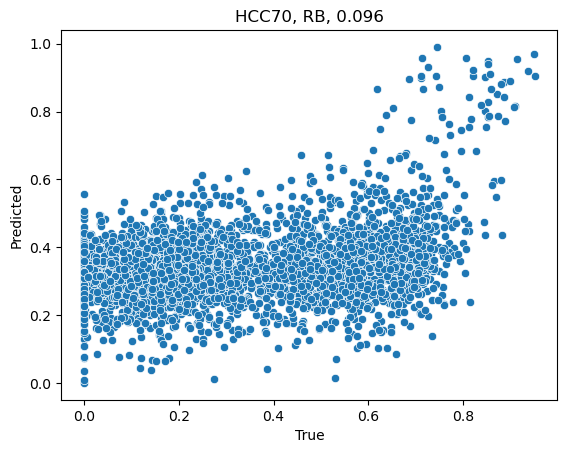

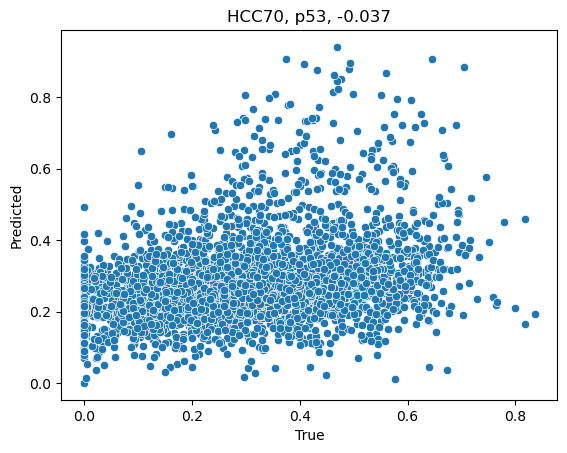

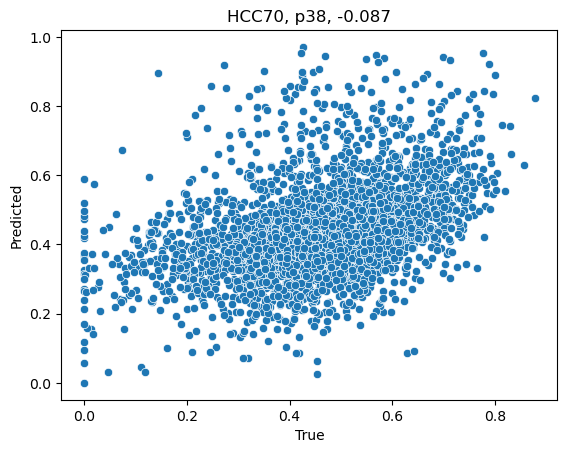

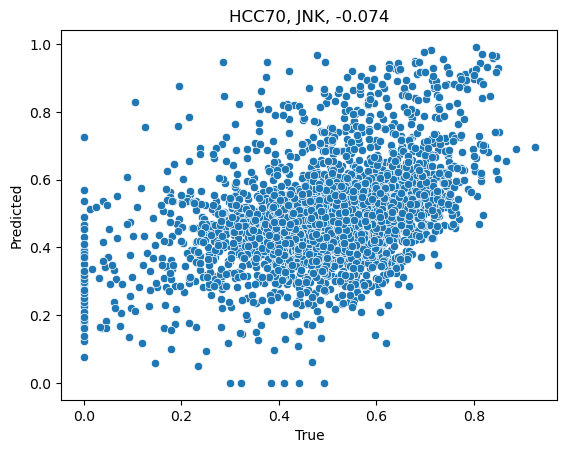

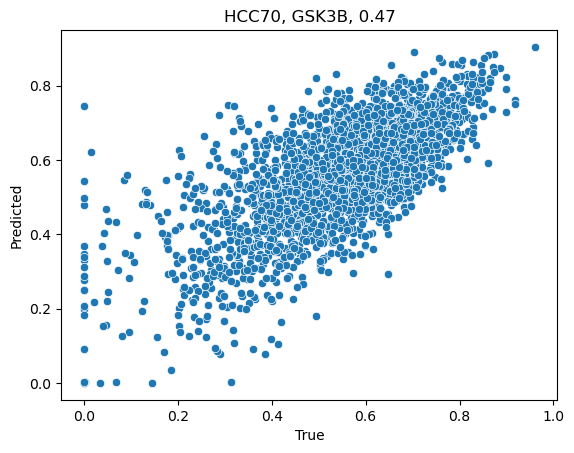

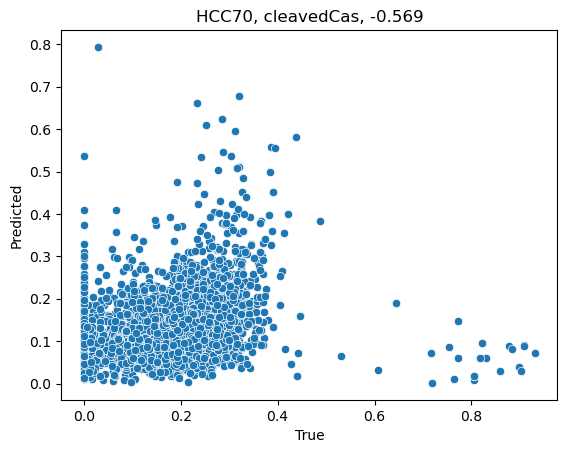

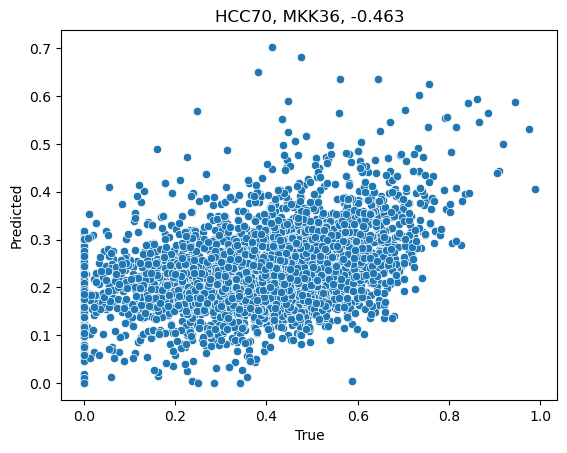

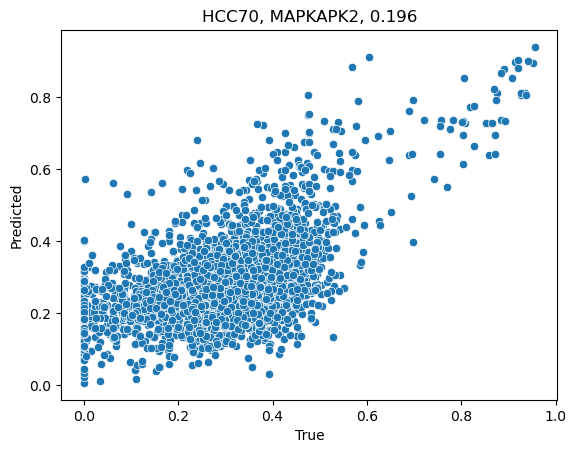

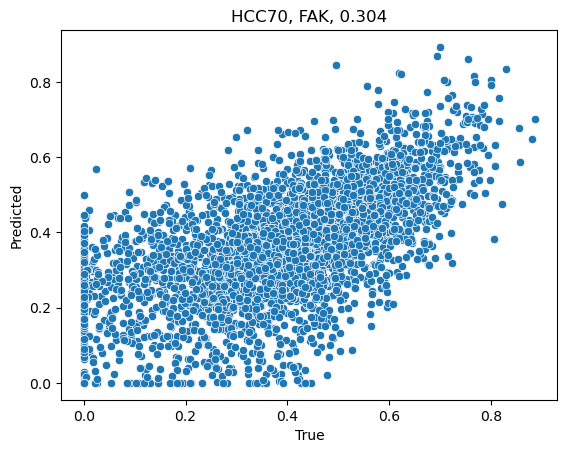

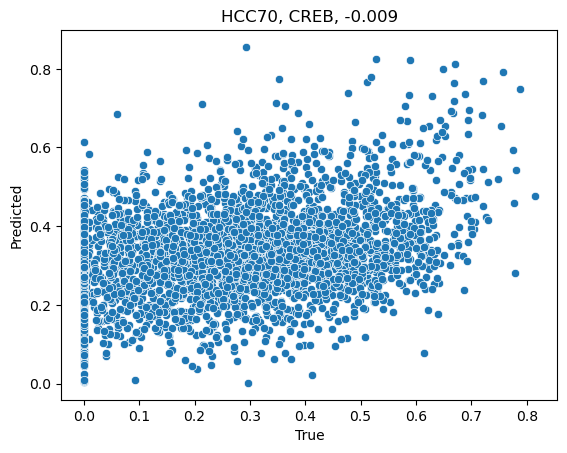

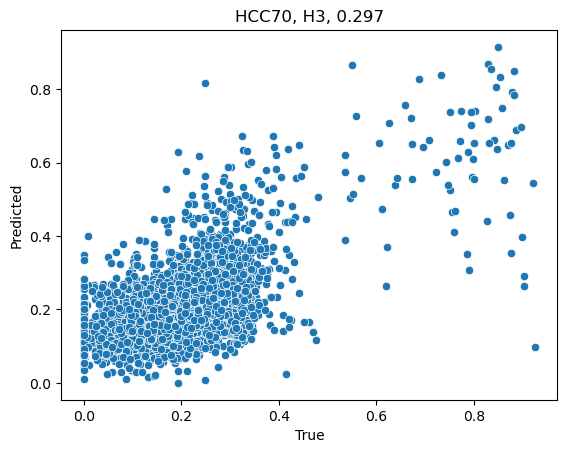

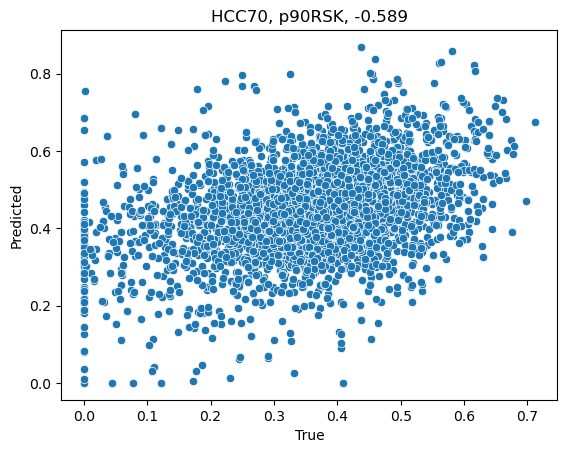

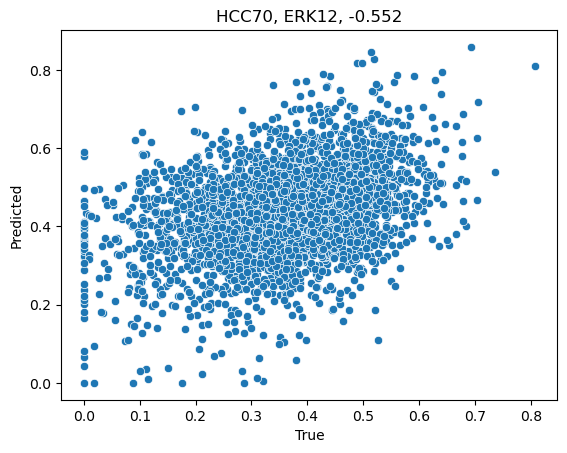

/Users/adr/miniconda3/envs/biofuzznet/lib/python3.10/site-packages/sklearn/base.py:288: UserWarning: Trying to unpickle estimator MinMaxScaler from version 1.2.2 when using version 1.2.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/adr/Projects/biological_fuzzy_logic_networks/biological_fuzzy_logic_networks/DREAM_analysis/utils.py:69: DtypeWarning: Columns (42) have mixed types. Specify dtype option on import or set low_memory=False.
  cl_data = pd.read_csv(data_file)
/Users/adr/Projects/biological_fuzzy_logic_networks/biological_fuzzy_logic_networks/DREAM_analysis/utils.py:287: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user

Scaler provided, ignoring `scale type`


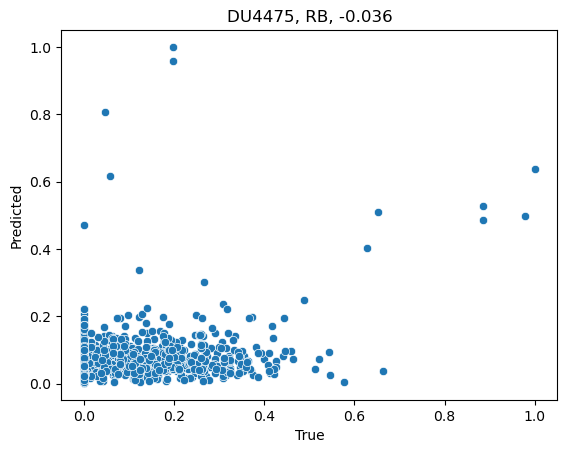

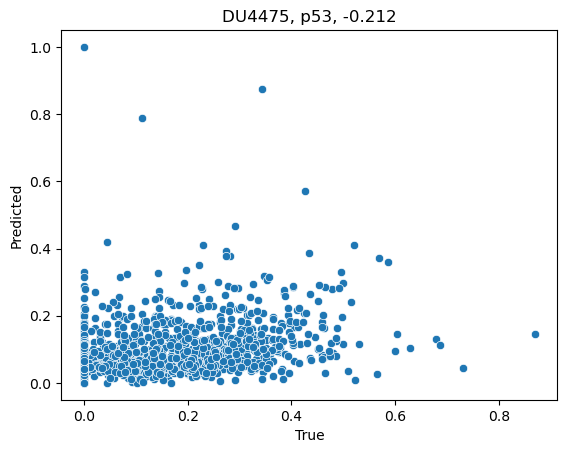

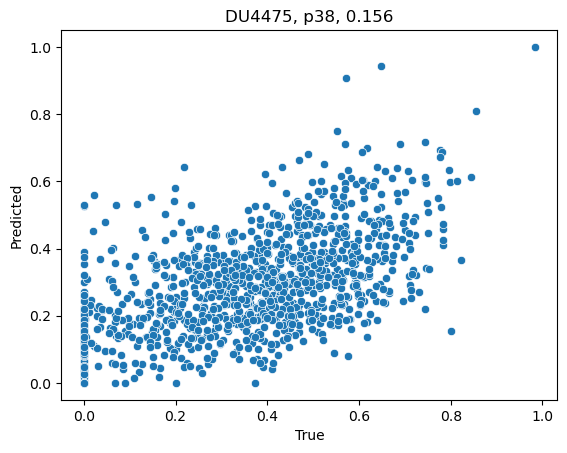

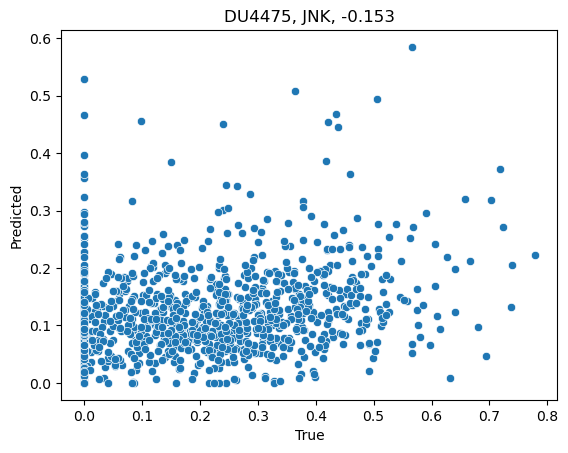

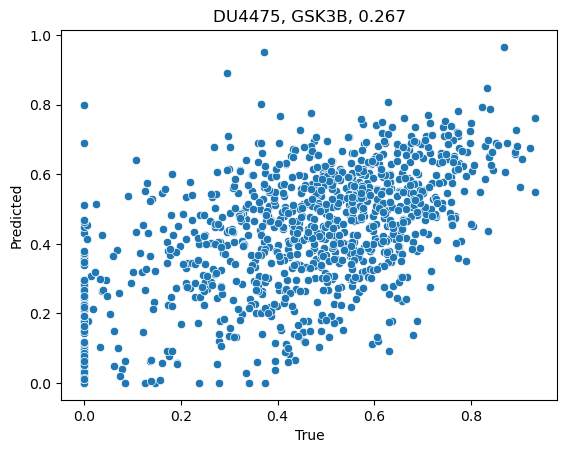

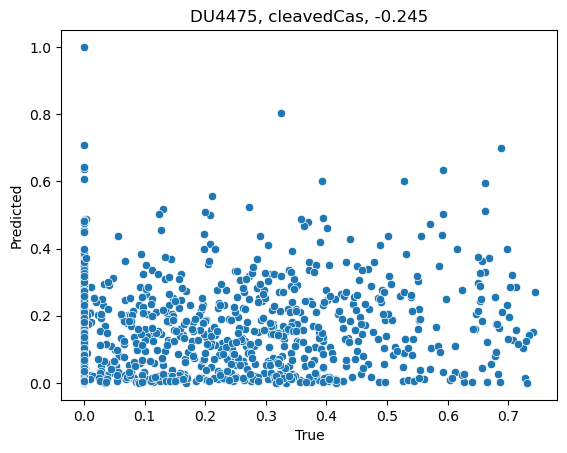

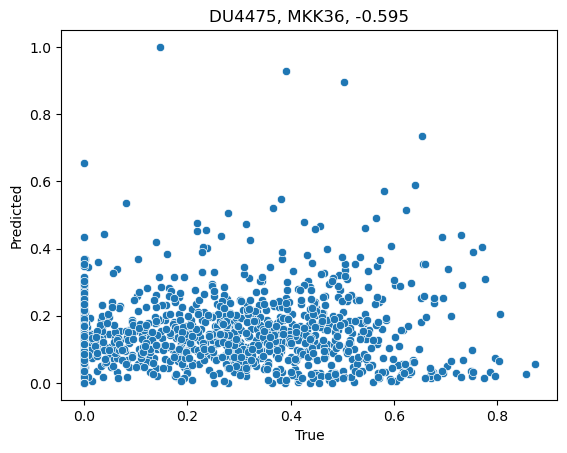

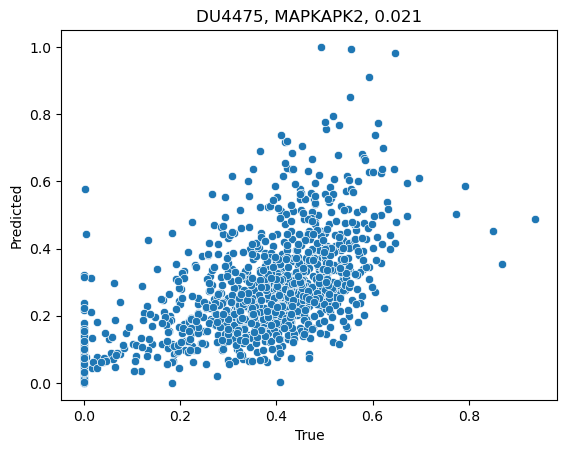

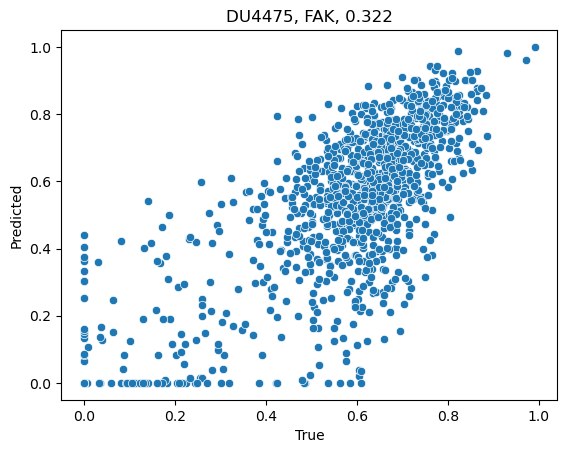

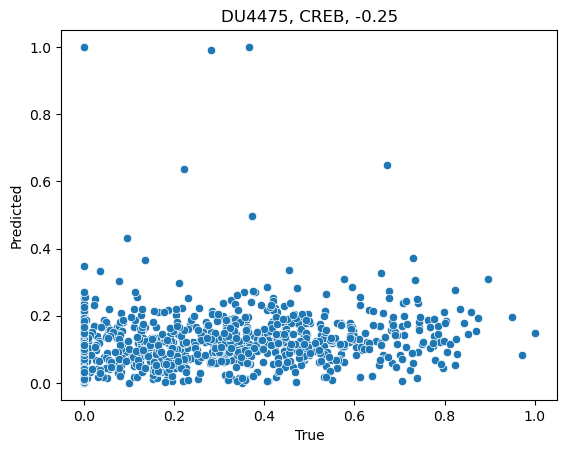

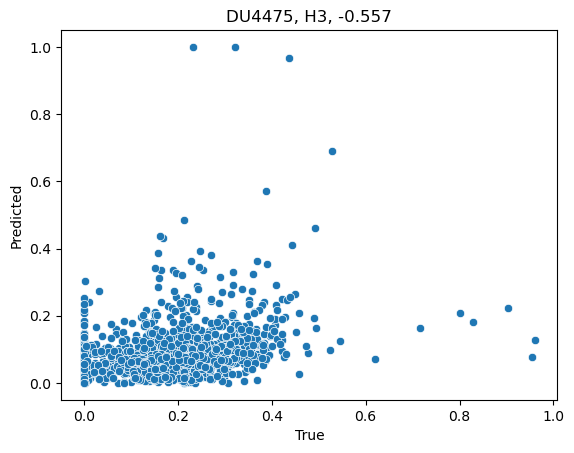

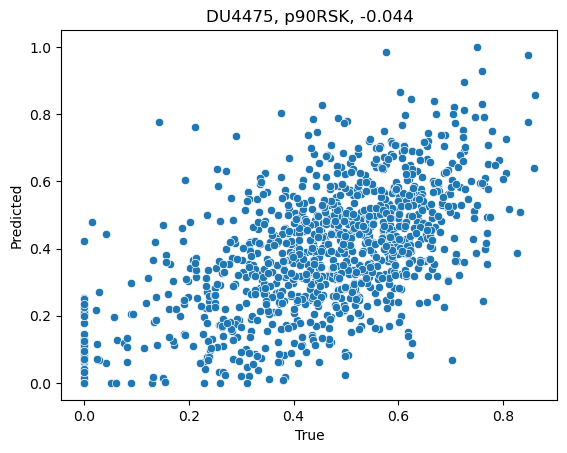

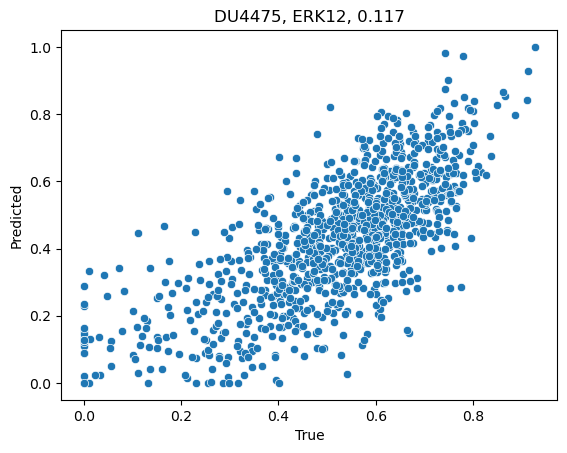

/Users/adr/miniconda3/envs/biofuzznet/lib/python3.10/site-packages/sklearn/base.py:288: UserWarning: Trying to unpickle estimator MinMaxScaler from version 1.2.2 when using version 1.2.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Scaler provided, ignoring `scale type`


/Users/adr/Projects/biological_fuzzy_logic_networks/biological_fuzzy_logic_networks/DREAM_analysis/utils.py:287: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t[t < 0] = 1e-9
/Users/adr/Projects/biological_fuzzy_logic_networks/biological_fuzzy_logic_networks/DREAM_analysis/utils.py:287: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t[t < 0] = 1e-9
/Users/adr/Projects/biological_fuzzy_logic_networks/biological_fuzzy_logic_networks/DREAM_analysis/utils.py:288: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc

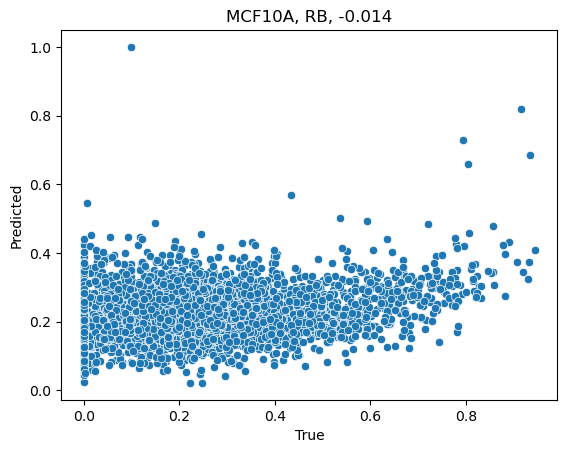

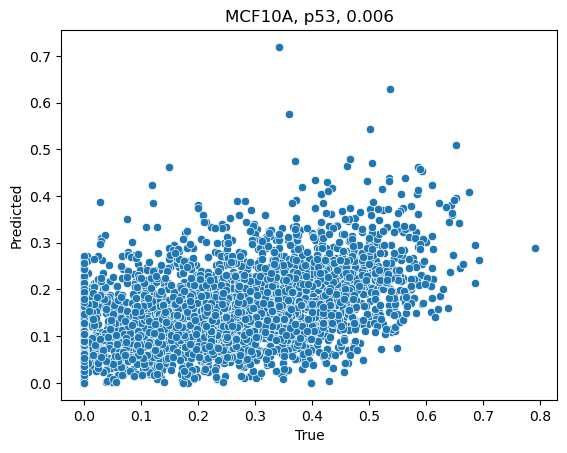

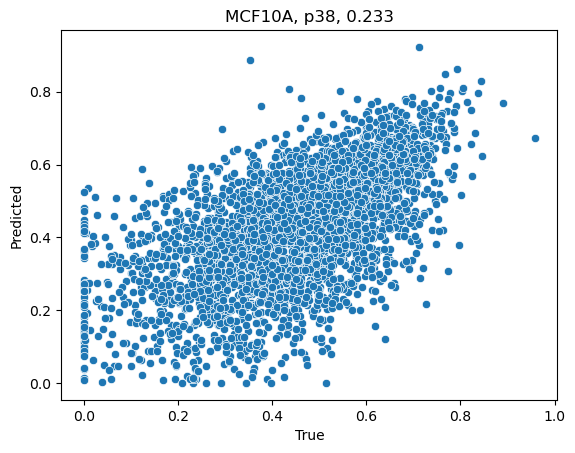

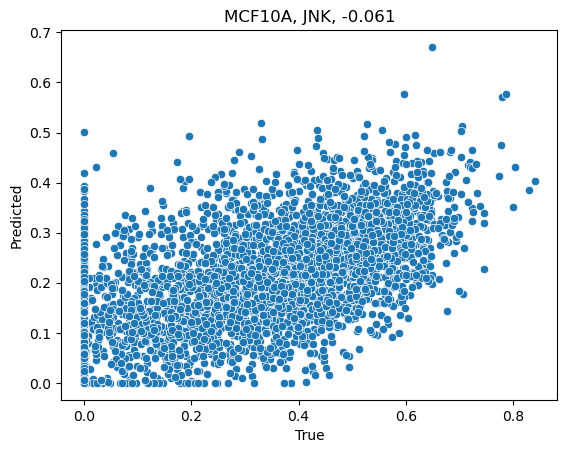

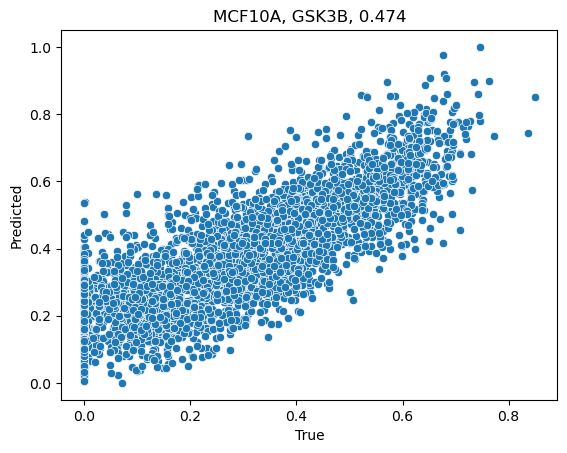

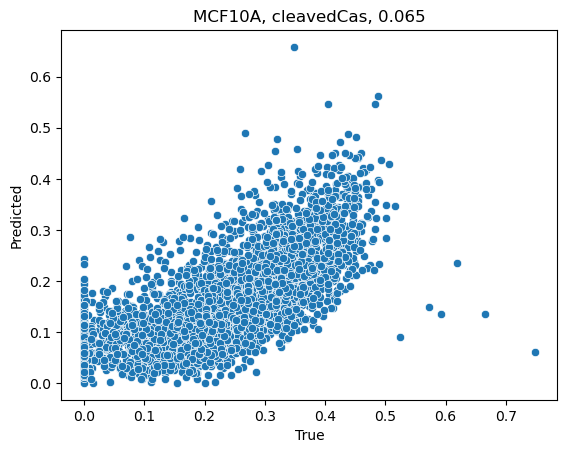

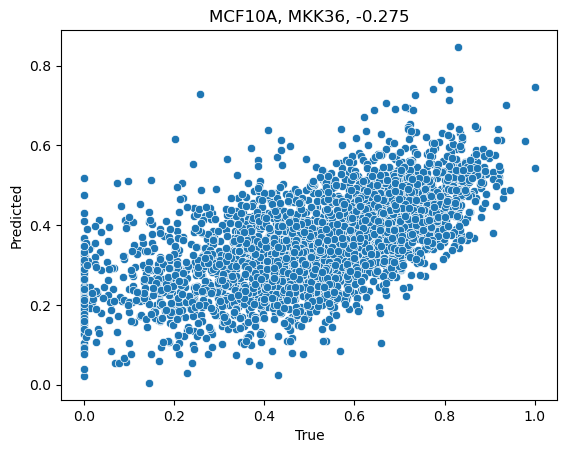

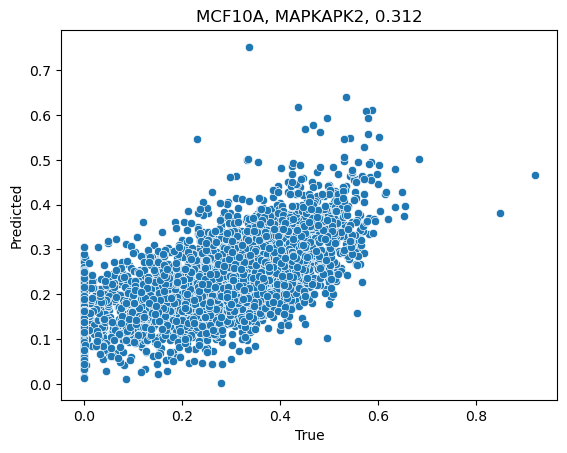

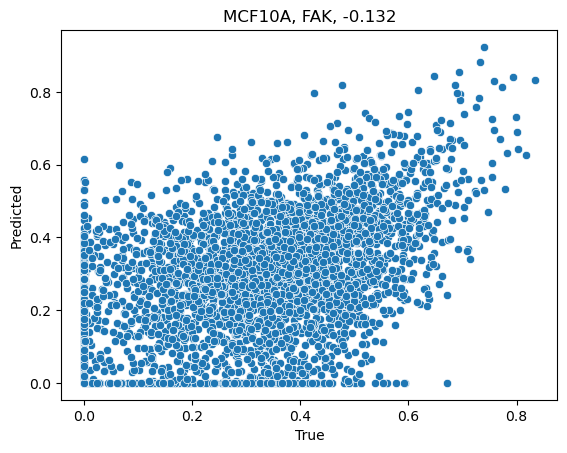

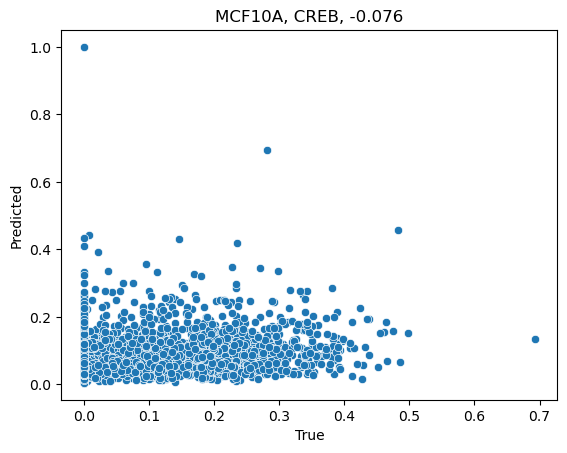

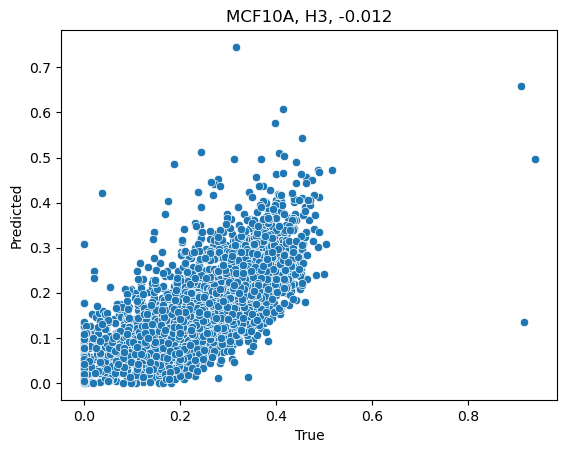

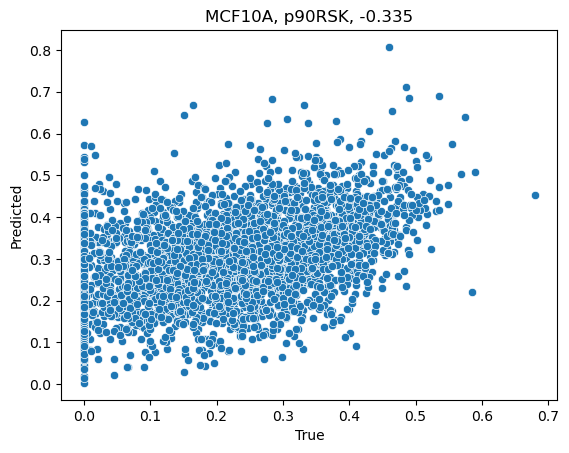

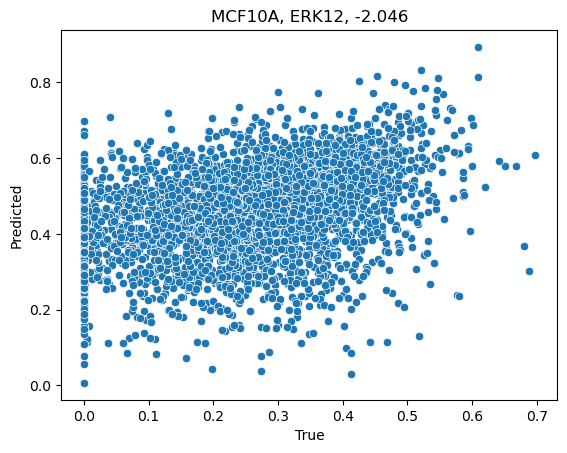

In [44]:
cell_lines = []
r2_scores = []
nodes = []
models = []
for cell_line in ["HCC70", "DU4475", "MCF10A"]:
    ckpt_path = f"/Users/adr/Box/BioFuzzNet/BFN/Model/After_synthetic/{cell_line}/"
    ckpt = torch.load(f"{ckpt_path}/model.pt", map_location=torch.device("cpu"))
    model = DREAMBioFuzzNet.build_DREAMBioFuzzNet_from_file(pkn_sif)
    model.load_from_checkpoint(ckpt["model_state_dict"])

    with open(f"{ckpt_path}scaler.pkl", "rb") as f:
            scaler = pickle.load(f)
    with open(f"/Users/adr/Box/BioFuzzNet/BFN/Model/After_synthetic/Configs/{cell_line}_config.json") as f:
        config = json.load(f)
    f.close()

    config["checkpoint_path"] = f"/Users/adr/Box/BioFuzzNet/BFN/Model/After_synthetic/{cell_line}/"
    config["data_file"] = f"/Users/adr/Box/BioFuzzNet/DREAMdata/Time_aligned_per_cell_line/CL_incl_test/{cell_line}.csv"
    config["output_dir"] = f"/Users/adr/Box/BioFuzzNet/BFN/Model/After_synthetic/{cell_line}/"
    
    
    cl_data = prepare_cell_line_data(
    data_file=config["data_file"],
    time_point=config["time_point"],
    non_marker_cols=config["non_marker_cols"],
    treatment_col_name=config["treatment_col_name"],
    filter_starved_stim=config["filter_starved_stim"],
    sample_n_cells=config["sample_n_cells"],
    sel_condition="iMEK",
    )

    # Load train and valid data
    (   train_data,
        valid_data,
        train_inhibitors,
        valid_inhibitors,
        train_input,
        valid_input,
        train,
        valid,
     scaler
    ) = cl_data_to_input(
        data=cl_data,
        model=model,
        train_treatments=None,
        valid_treatments=None,
        train_cell_lines=None,
        valid_cell_lines=None,
        inhibition_value=1.5,
        add_root_values=config["add_root_values"],
        input_value=config["input_value"],
        root_nodes=config["root_nodes"],
        replace_zero_inputs=config["replace_zero_inputs"],
        balance_data=True,
        scaler=scaler
    )
    
    valid = valid.reset_index(drop=True)
    
    with torch.no_grad():
        model.initialise_random_truth_and_output(len(valid))
        model.set_network_ground_truth(valid_data)
        model.sequential_update(model.root_nodes, valid_inhibitors)
        pred = pd.DataFrame(
            {k: v.cpu().numpy() for k, v in model.output_states.items()}
        ).reset_index(drop=True)
        
        
    # Linear model OOD
    with open(f"/Users/adr/Box/BioFuzzNet/BFN/Model/After_synthetic/{cell_line}/LM_{cell_line}_EGF.pkl", "rb") as f:
        model = pickle.load(f)
        
    eval_markers = ["RB", "p53", "p38", "JNK", "GSK3B", "cleavedCas", "MKK36", "MAPKAPK2", 
                "FAK", "CREB", "H3", "p90RSK", "ERK12"]
    lm_pred = pd.DataFrame(model.predict(valid[model.feature_names_in_]), columns=eval_markers)

    for node in eval_markers:
        r2 = r2_score(valid[node], pred[node])
        r2_scores.append(r2)
        cell_lines.append(cell_line)
        nodes.append(node)
        models.append("BFN")
        
        lm_r2 = r2_score(valid[node], lm_pred[node])
        r2_scores.append(lm_r2)
        cell_lines.append(cell_line)
        nodes.append(node)
        models.append("LM")
        
        sns.scatterplot(x=valid[node], y=pred[node])
        plt.xlabel("True")
        plt.ylabel("Predicted")
        plt.title(f"{cell_line}, {node}, {round(r2, 3)}")
        plt.show()


In [45]:
results = pd.DataFrame({"cell line": cell_lines, "node": nodes, "r2": r2_scores, "model": models})
results

,cell line,node,r2,model
0,HCC70,RB,0.095623,BFN
1,HCC70,RB,0.170594,LM
2,HCC70,p53,-0.037470,BFN
3,HCC70,p53,0.245186,LM
4,HCC70,p38,-0.086646,BFN
...,...,...,...,...
73,MCF10A,H3,0.565330,LM
74,MCF10A,p90RSK,-0.335437,BFN
75,MCF10A,p90RSK,-1.798593,LM
76,MCF10A,ERK12,-2.046043,BFN


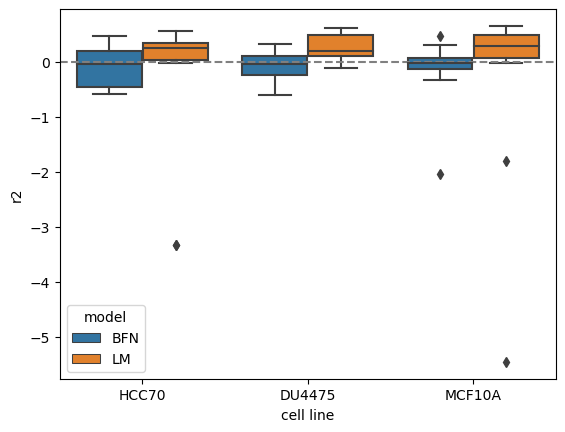

In [46]:
sns.boxplot(data=results, x="cell line", y="r2", hue="model")
plt.axhline(y=0, color="grey", linestyle="--")

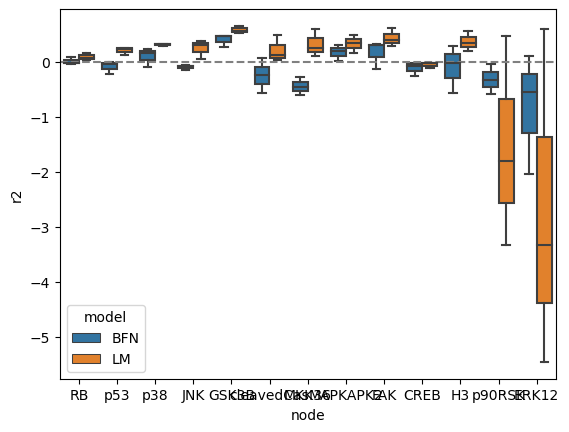

In [47]:
sns.boxplot(data=results, x="node", y="r2", hue="model")
plt.axhline(y=0, color="grey", linestyle="--")

In [3]:
ckpt_path = f"/Users/adr/Box/BioFuzzNet/BFN/Model/After_synthetic/{cell_line}/"

In [4]:
ckpt = torch.load(f"{ckpt_path}/model.pt", map_location=torch.device("cpu"))
model = DREAMBioFuzzNet.build_DREAMBioFuzzNet_from_file(pkn_sif)
model.load_from_checkpoint(ckpt["model_state_dict"])

with open(f"{ckpt_path}scaler.pkl", "rb") as f:
        scaler = pickle.load(f)

/Users/adr/miniconda3/envs/biofuzznet/lib/python3.10/site-packages/sklearn/base.py:288: UserWarning: Trying to unpickle estimator MinMaxScaler from version 1.2.2 when using version 1.2.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
model

In [6]:
with open(f"/Users/adr/Box/BioFuzzNet/BFN/Model/After_synthetic/Configs/{cell_line}_config.json") as f:
    config = json.load(f)
f.close()
config

{'pkn_sif': '/dccstor/ipc1/CAR/DREAM/DREAMdata/Alice_subnetwork.sif',
 'network_class': 'DREAMBioFuzzNet',
 'data_file': '/dccstor/ipc1/CAR/DREAM/DREAMdata/Time_aligned_per_cell_line/CL_incl_test/HCC70.csv',
 'output_dir': '/dccstor/ipc1/CAR/DREAM/Model/Test/After_synthetic/HCC70/MSLE/',
 'loss_function': 'MSLE',
 'time_point': 9,
 'non_marker_cols': ['treatment', 'cell_line', 'time'],
 'treatment_col_name': 'treatment',
 'sel_condition': 'EGF',
 'sample_n_cells': False,
 'filter_starved_stim': True,
 'add_root_values': True,
 'root_nodes': ['EGFR'],
 'input_value': 1,
 'train_treatments': None,
 'valid_treatments': None,
 'train_cell_lines': None,
 'valid_cell_lines': None,
 'convergence_check': False,
 'replace_zero_inputs': 1e-09,
 'inhibition_value': 1.0,
 'learning_rate': 0.001,
 'n_epochs': 800,
 'batch_size': 500,
 'checkpoint_path': '/dccstor/ipc1/CAR/DREAM/Model/Test/After_synthetic/HCC70/MSLE/',
 'experiment_name': 'OneCellLine',
 'optimizer': 'SGD',
 'scale_type': 'minmax',


In [8]:
config["checkpoint_path"] = f"/Users/adr/Box/BioFuzzNet/BFN/Model/After_synthetic/{cell_line}/"
config["data_file"] = f"/Users/adr/Box/BioFuzzNet/DREAMdata/Time_aligned_per_cell_line/CL_incl_test/{cell_line}.csv"
config["output_dir"] = f"/Users/adr/Box/BioFuzzNet/BFN/Model/After_synthetic/{cell_line}/"

In [9]:
cl_data = prepare_cell_line_data(
    data_file=config["data_file"],
    time_point=config["time_point"],
    non_marker_cols=config["non_marker_cols"],
    treatment_col_name=config["treatment_col_name"],
    filter_starved_stim=config["filter_starved_stim"],
    sample_n_cells=config["sample_n_cells"],
    sel_condition="iMEK",
)

# Load train and valid data
(   train_data,
    valid_data,
    train_inhibitors,
    valid_inhibitors,
    train_input,
    valid_input,
    train,
    valid,
 scaler
) = cl_data_to_input(
    data=cl_data,
    model=model,
    train_treatments=None,
    valid_treatments=None,
    train_cell_lines=None,
    valid_cell_lines=None,
    inhibition_value=1.5,
    add_root_values=config["add_root_values"],
    input_value=config["input_value"],
    root_nodes=config["root_nodes"],
    replace_zero_inputs=config["replace_zero_inputs"],
    balance_data=True,
    scaler=scaler
)

/Users/adr/Projects/biological_fuzzy_logic_networks/biological_fuzzy_logic_networks/DREAM_analysis/utils.py:69: DtypeWarning: Columns (42) have mixed types. Specify dtype option on import or set low_memory=False.
  cl_data = pd.read_csv(data_file)


Scaler provided, ignoring `scale type`


/Users/adr/Projects/biological_fuzzy_logic_networks/biological_fuzzy_logic_networks/DREAM_analysis/utils.py:287: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t[t < 0] = 1e-9
/Users/adr/Projects/biological_fuzzy_logic_networks/biological_fuzzy_logic_networks/DREAM_analysis/utils.py:287: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t[t < 0] = 1e-9
/Users/adr/Projects/biological_fuzzy_logic_networks/biological_fuzzy_logic_networks/DREAM_analysis/utils.py:288: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc

In [10]:
with torch.no_grad():
    model.initialise_random_truth_and_output(len(valid))
    model.set_network_ground_truth(valid_data)
    model.sequential_update(model.root_nodes, valid_inhibitors)
    val_output_states = pd.DataFrame(
        {k: v.cpu().numpy() for k, v in model.output_states.items()}
    )



In [11]:
node_r2_scores = {}
for node in valid_data.keys():
    node_r2_scores[f"val_r2_{node}"] = r2_score(
        valid[node], val_output_states[node]
    )

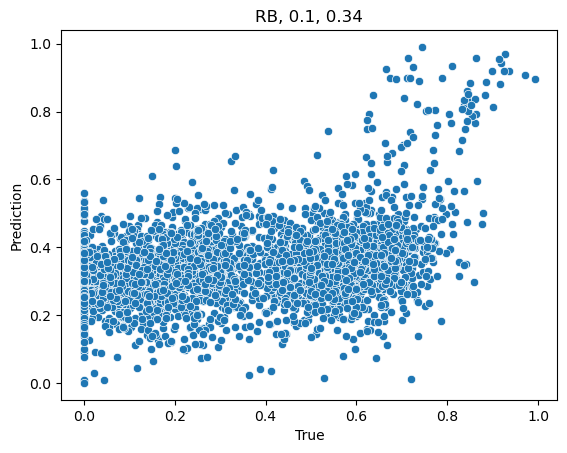

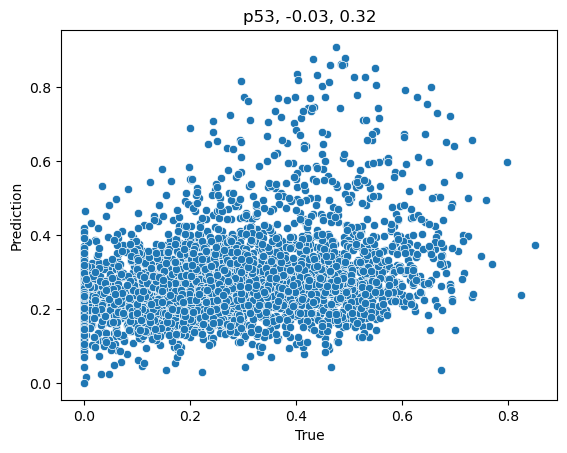

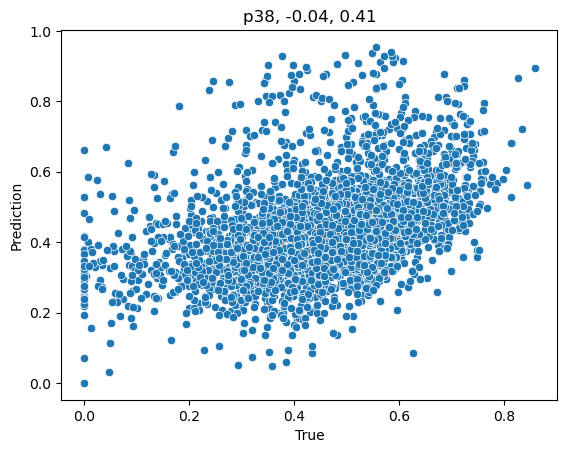

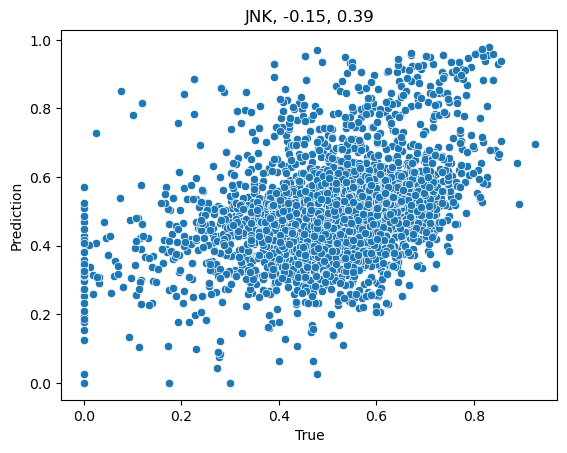

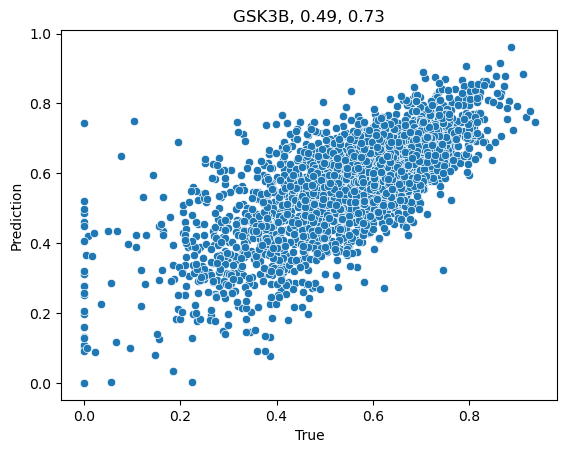

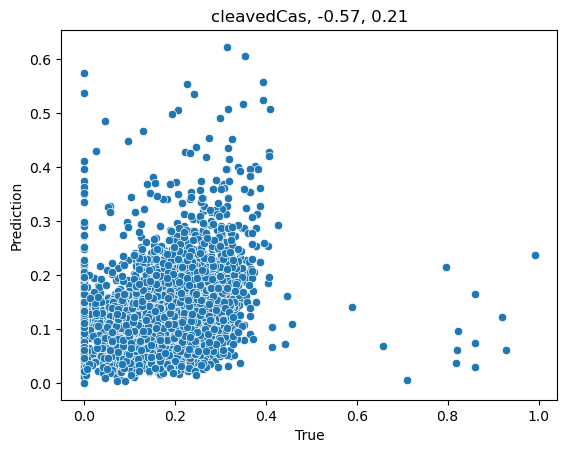

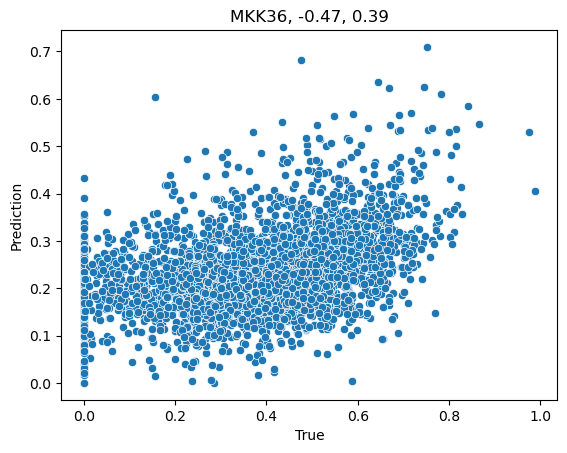

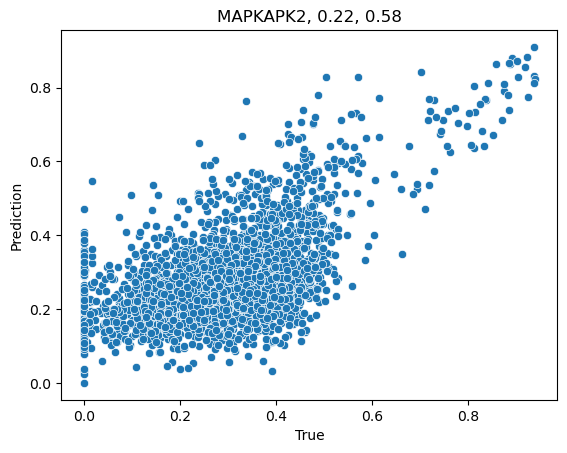

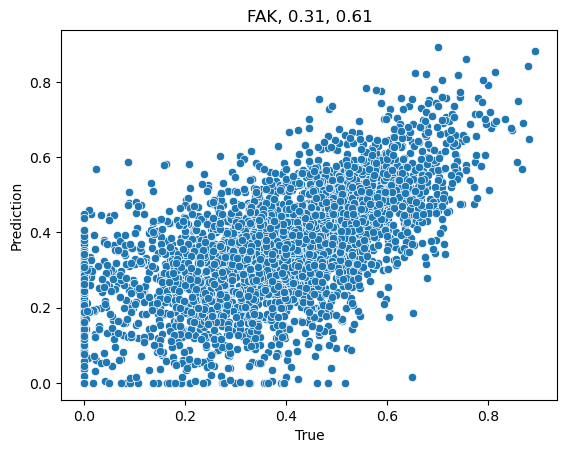

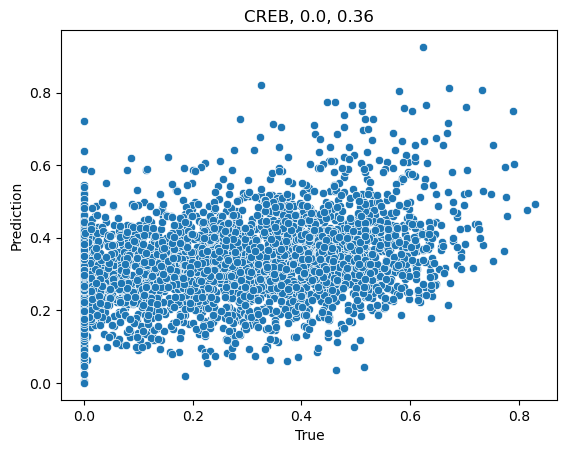

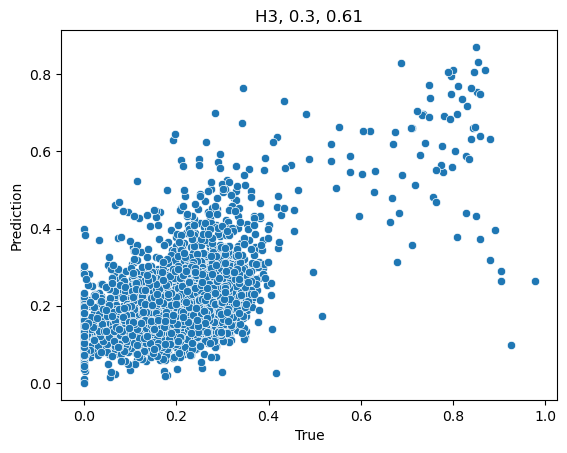

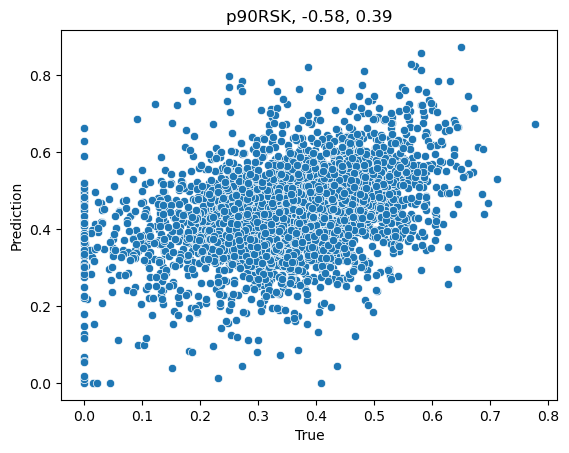

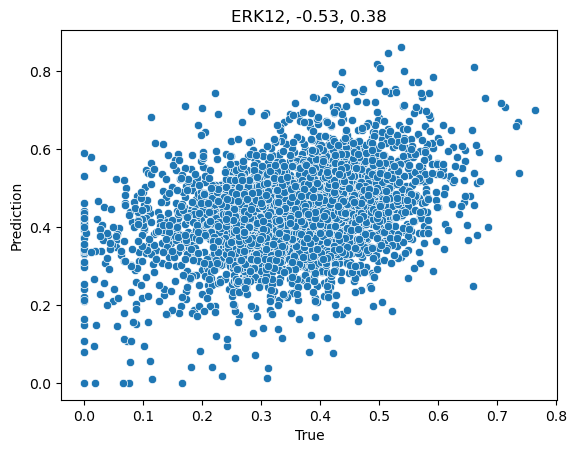

In [12]:
eval_markers = ["RB", "p53", "p38", "JNK", "GSK3B", "cleavedCas", "MKK36", "MAPKAPK2", 
                "FAK", "CREB", "H3", "p90RSK", "ERK12"]
valid=valid.reset_index(drop=True)
r2_scores = []
correlations = []
for marker in eval_markers:
    corr = valid[marker].corr(val_output_states[marker], method='pearson')
    correlations.append(corr)
    r2 = r2_score(valid[marker], val_output_states[marker])
    r2_scores.append(r2)
    sns.scatterplot(x=valid[marker], y=val_output_states[marker])
    plt.xlabel("True")
    plt.ylabel("Prediction")
    plt.title(f"{marker}, {round(r2, 2)}, {round(corr, 2)}")
    plt.show()

In [22]:
pred_nodes_r2 = {n.split("_")[-1]: r2 for n, r2 in node_r2_scores.items() if n.split("_")[-1] in eval_markers}

In [31]:
r2_scores = pd.DataFrame.from_dict(pred_nodes_r2, orient="index").reset_index().rename(columns={0: "r2", "index": "node"})
r2_scores["cell line"] = cell_line
r2_scores

NameError: name 'cell_line' is not defined

{'val_r2_cleavedCas': -0.5674603077842024,
 'val_r2_AKT_S473': 1.0,
 'val_r2_AKT_T308': 1.0,
 'val_r2_AMPK': 1.0,
 'val_r2_CREB': 0.0003345520740872798,
 'val_r2_ERK12': -0.5338332413110041,
 'val_r2_FAK': 0.3121031133928308,
 'val_r2_GSK3B': 0.4899415967312657,
 'val_r2_H3': 0.2984566627333485,
 'val_r2_JNK': -0.14927221243775812,
 'val_r2_MAPKAPK2': 0.21959172450485498,
 'val_r2_MEK12': 1.0,
 'val_r2_MKK36': -0.4682837422187782,
 'val_r2_MKK4': 1.0,
 'val_r2_p38': -0.038107080953644124,
 'val_r2_p53': -0.025394289652438395,
 'val_r2_p90RSK': -0.5775769453876758,
 'val_r2_RB': 0.10310334277558553,
 'val_r2_SMAD23': 1.0,
 'val_r2_SRC': 1.0}